# Scale up the Gauss-Newton for much large problems using the new construction 

See 'toshow' notebook for a demonstration of what I'm trying to rewrite in a more streamlined verison. 

In [1]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag

# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Module definition

We're doing just a simple MLP with *differing* dimensions, but also be able to store the global adjoints.

However, I found a much easier solution without resorting to append adjoints, by using the Linen `perturb`

### Old adjoint code; should fold away


In [2]:
def append_adjoints(adjoints):
    # print(adjoints)
    global_adjoints.append(adjoints)

class AdjointHook(nn.Module):
    """
    A wrapper module that applies a custom VJP to any given layer
    to capture its incoming gradient (adjoint) during the backward pass.
    """
    layer: nn.Module  # The layer to wrap

    @nn.compact
    def __call__(self, *args, **kwargs):
        # Define the function to which we'll attach the custom VJP
        @jax.custom_vjp
        def layer_with_hook(params, *args, **kwargs):
            return self.layer.apply(params, *args, **kwargs)

        def layer_fwd(params, *args, **kwargs):
            output = self.layer.apply(params, *args, **kwargs)
            return output, (params, args, kwargs)

        def layer_bwd(res, g):
            params, args, kwargs = res

            # Calculate the VJP of the original wrapped layer
            # This computes the gradients w.r.t. params and inputs
            _, vjp_fun = jax.vjp(
                lambda p, *a, **kw: self.layer.apply(p, *a, **kw), params, *args, **kwargs
            )
            
            # The VJP function returns a tuple of gradients
            grad_params, *grad_args = vjp_fun(g)

            # Need to store here
            global_adjoints.append(grad_args[0])
            # jax.debug.callback(append_adjoints, grad_args[0])

            return (grad_params,) + tuple(grad_args)

        # Attach the custom forward and backward functions
        layer_with_hook.defvjp(layer_fwd, layer_bwd)
        
        # Get the parameters for the wrapped layer
        layer_params = self.param('wrapped_layer', self.layer.init, *args, **kwargs)

        return layer_with_hook(layer_params, *args, **kwargs)


## MLP code

Just the models; note the self.perturb in the layers.

In [3]:
class MLP_Layer(nn.Module):
    num_units: int
    def setup(self):
        self.dense1 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
        self.dense2 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
    def __call__(self, x):
        f = self.dense1(x)
        f = nn.tanh(f)
        f = self.dense2(f)
        return f 

# Define the MLP module
class MLP(nn.Module):
    features: Sequence[int]
    
    def setup(self):
        layers = []
        for _, dim in enumerate(self.features):
            layers.append(
                # This AdjointHook is not needed anymore
                # AdjointHook(MLP_Layer(
                #     num_units=dim
                # ))
                MLP_Layer(
                    num_units=dim
                )

            )
        self.layers = tuple(layers)

    def __call__(self, x: jnp.ndarray):
        self.sow('intermediates', f'layer_{0}_output', x)
        for i, layer in enumerate(self.layers):
            x = self.perturb(f'layer_{i+1}', x)
            x = layer(x)
            self.sow('intermediates', f'layer_{i+1}_output', x)
        return x



In [4]:
n = 10
n_samples = 8

X = jax.random.normal(jax.random.PRNGKey(0), (n_samples, n))

key = jax.random.PRNGKey(0)
model = MLP(features=[16, 16, 16, 1])
params = model.init(key, jnp.ones((1, n))) # Notice here that params has "perturbations" in it.
params, perturbations = params['params'], params['perturbations']
output, intermediates = model.apply(
    {'params': params, 'perturbation': perturbations}, X, mutable=['intermediates']
)
# intermediates

## Global adjoints

For now, we simply use the `jax.jacobian` rather than a clever thing; a bit larger memory footprint but the inversion is the time killer.

In [5]:
jacobian = jax.jacobian(model.apply, argnums=0)({'params': params, 'perturbation': perturbations}, X)['params']
flattened, _ = jax.tree.flatten(
    jacobian
)

# Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
reshaped_leaves = [leaf.reshape(n_samples * model.features[-1], 1, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
J = aggregated_array.reshape((n_samples * model.features[-1], -1))
treescope.display(J)

In [6]:
global_adjoints = []

# To grab the gradient wrt to the adjoints/residuals, we take the Jacobian wrt to the perturbations!
jacobian = jax.jacobian(
    lambda params, perturbations, X: model.apply({'params': params, 'perturbations': perturbations}, X), argnums=1
)(params, perturbations, X)
flattened, _ = jax.tree.flatten(
    jacobian
)
# It's weird that the perturbations are this dimensions, but it's easy to reshape them to what we need
together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
global_adjoints = [
    block_diag(*jnp.split(leaf, n_samples, axis=0)) for leaf in together
]

global_adjoints.append(jnp.eye(J.shape[0]))


In [7]:
global_adjoints

[<jax.Array float64(8, 80) ≈-0.00077 ±0.061 [≥-0.48, ≤0.33] zero:560 nonzero:80
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(8, 128) ≈-0.0053 ±0.084 [≥-0.7, ≤0.44] zero:896 nonzero:128
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(8, 128) ≈-0.0017 ±0.088 [≥-0.7, ≤0.6] zero:896 nonzero:128
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(8, 128) ≈0.011 ±0.11 [≥-0.62, ≤0.63] zero:896 nonzero:128
   <Arrayviz rendering>
 | Device: GPU 0>,
 <jax.Array float64(8, 8) ≈0.12 ±0.33 [≥0.0, ≤1.0] zero:56 nonzero:8
   <Arrayviz rendering>
 | Device: GPU 0>]

### Layer by Layer

Now need a good way of extracting the layer by layer. Might be better to preprocess, and store?

In [8]:
prediction, intermediates = model.apply({'params': params}, X, mutable=['intermediates'])

def get_layer_params(model: nn.Module, params: dict, layer_num: int, intermediates: jnp.ndarray):
    """
    Given the MLP model from above; extract out the layer, take the
    """
    layer = MLP_Layer(num_units=model.features[layer_num])

    def apply_layer(params):
        return layer.apply(
            params,
            intermediates['intermediates'][f'layer_{layer_num}_output'][0]
        )
    k_i = jax.jacrev(apply_layer)
    flattened, _ = jax.tree.flatten(
            k_i({'params': params[f'layers_{layer_num}']})
    )
    reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1) #.reshape(n * n_samples, -1)

    return aggregated_array

# print(model.features)
# print(params[f'layers_{0}'])
get_layer_params(model, params, 0, intermediates)

<jax.Array float32(128, 448) ≈0.0032 ±0.17 [≥-1.4, ≤1.4] zero:32_640 nonzero:24_704
  <Arrayviz rendering>
| Device: GPU 0>

In [9]:
k_list = []
for l in range(len(model.features)):
    k_list.append(get_layer_params(model, params, l, intermediates))


In [10]:
# k_list

## Let's verify again that the Jacobian can be computed like this

In [11]:
print(model.features, X.shape)
J

[16, 16, 16, 1] (8, 10)


<jax.Array float32(8, 1555) ≈0.0027 ±0.16 [≥-1.1, ≤1.4] nonzero:12_440
  <Arrayviz rendering>
| Device: GPU 0>

In [12]:
# Size of (n \times k) \times (n \times k)
sum_mat = jnp.eye(J.shape[0])
lamb = 0.1

# For each layer
for i in range(len(model.features)):
    # Each dgdt item is (n \times k) \times (p_i) where p_i
    # is parameter of that layer
    middle = k_list[i] @ k_list[i].T
    # Adjoints is really scaling as n * k**2
    sum_mat += global_adjoints[i+1] @ middle @ global_adjoints[i+1].T / lamb


print(
    jnp.linalg.norm(sum_mat - (jnp.eye(J.shape[0]) + J @ J.T/lamb))
)
# sum_mat

0.00010060710739008168


In [13]:
jnp.linalg.norm(sum_mat - (jnp.eye(J.shape[0]) + J @ J.T/lamb))


<jax.Array(0.00010061, dtype=float64)>

## Let's write a thing which given the two lists and the input gradient, will figure this out

In [14]:
@jax.jit # This takes list, and makes them static; can be jitted easily
def get_correction(k_list, global_adjoints, grad, lamb: float=1e-1):
    """
    Assumes grad is a vector
    """
    p_list = [k.shape[1] for k in k_list]
    p_list.insert(0, 0)
    indices = list(itertools.accumulate(p_list))
    j_shape = global_adjoints[0].shape[0]

    # Use the SMW formulation; first do Jv
    aux_var = jnp.zeros(j_shape)
    for i in range(len(model.features)):
        aux_var += global_adjoints[i+1] @ (k_list[i] @ grad[indices[i]:indices[i+1]])

    # Calculate I + 1 / lamb JJ^T and get its inverse
    sum_mat = jnp.eye(j_shape)
    for i in range(len(model.features)):
        sum_mat += global_adjoints[i+1] @ (k_list[i] @ k_list[i].T) @ global_adjoints[i+1].T / lamb
    aux_var = jnp.linalg.solve(sum_mat, aux_var)

    # Finally do J^T v and scale
    out = jnp.concat([k_list[i].T @ (global_adjoints[i+1].T @ aux_var) for i in range(len(model.features))]) / (lamb ** 2)

    # Don't forget the 1/lambda I
    return -out + grad / lamb

@jax.jit
def test_normal_inverse(J, grad, lamb: float=1e-1):
    return jnp.linalg.solve(jnp.eye(J.shape[1]) + lamb * J.T @ J, grad)

grad = jnp.arange(J.shape[1],) * 2
test_normal_inverse(J, grad, lamb=1e-2)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e1)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e0)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e-2)
jnp.linalg.norm(jnp.linalg.solve(jnp.eye(J.shape[1]) * 1e-2 + J.T @ J, grad) - my_correct) / (my_correct.T @ my_correct)

<jax.Array(2.70803741e-12, dtype=float64)>

In [15]:
get_correction(k_list, global_adjoints, grad, lamb=1e0)
%timeit get_correction(k_list, global_adjoints, grad, lamb=1e0).block_until_ready()

271 μs ± 487 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
test_normal_inverse(J, grad, lamb=1e-2)
%timeit test_normal_inverse(J, grad, lamb=1e-2).block_until_ready()

6.59 ms ± 1.59 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## With the above now we need to solve some problems

Let's try to learn a simple functional regression problem;

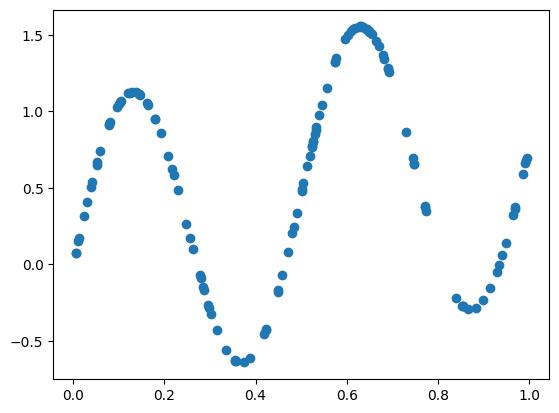

In [17]:
num_samples = 128
X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
y = jnp.sin(4 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)

In [18]:
def train_model_sgd(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, batch_y):
        def loss_fn(params):
            predictions = state.apply_fn(params, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn({'params': state.params})
        state = state.apply_gradients(grads=grads['params'])
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for _ in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        losses.append(loss)

    return state, losses

num_epochs = 5_000

key = jax.random.PRNGKey(0)

model = MLP(features=[16, 16, 16, 16, 16, 16, 1])
params = model.init(key, jnp.ones((1, 1)))
print(sum(x.size for x in jax.tree_leaves(params['params'])))
 
# Train the model
trained_state_sgd, sgd_losses = train_model_sgd(
    X, y, model, params, learning_rate=2e-3, num_epochs=num_epochs
)

3043
Starting training for 5000 epochs...


/tmp/ipykernel_3864282/2713991671.py:35: DeprecationWarning: jax.tree_leaves is deprecated: use jax.tree.leaves (jax v0.4.25 or newer) or jax.tree_util.tree_leaves (any JAX version).
  print(sum(x.size for x in jax.tree_leaves(params['params'])))


  0%|          | 0/5000 [00:00<?, ?it/s]

In [19]:
def train_model_precond(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    # Grab the functions for each layer and store it in list
    # ks = []
    # for layer_num in range(len(model.features)):
    #     ks.append(k_i)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        def loss_fn(params):
            predictions = state.apply_fn(params, batch_X)
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn({'params': state.params})

        new = True
        # ---------------- new jacobian stuff
        if new: 
            jacobian = jax.jacobian(
                lambda params, perturbations, batch_X:
                    state.apply_fn({'params': params, 'perturbations': perturbations}, X), argnums=1
            )(state.params, params['perturbations'], X)
            flattened, _ = jax.tree.flatten(
                jacobian
            )
            together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
            global_adjoints = [
                block_diag(*jnp.split(leaf, len(batch_X), axis=0)) for leaf in together
            ]
            global_adjoints.append(jnp.eye(batch_X.shape[0]))
    
            # Evaluate layers; refactor later
            _, intermediates = state.apply_fn(
                {'params': state.params}, batch_X, mutable=['intermediates']
            )
    
            k_list = []
            for layer_num in range(len(model.features)):
                layer = MLP_Layer(num_units=model.features[layer_num])
                def apply_layer(params):
                    return layer.apply(
                        params,
                        intermediates['intermediates'][f'layer_{layer_num}_output'][0]
                        # intermediates['intermediates'][f'layer_{layer_num}_output'][0]
                    )
                k_i = jax.jacrev(apply_layer, argnums=0)
                flattened, _ = jax.tree.flatten(
                    k_i(
                    {'params': state.params[f'layers_{layer_num}']}
                ))
    
                reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
                aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
                k_list.append(aggregated_array)
    
            flattened, back = jax.flatten_util.ravel_pytree(grads)
            altered = get_correction(
                k_list, global_adjoints, flattened,lamb=1e-1
            )
            grads = back(altered)
    
            state = state.apply_gradients(grads=grads['params'])
        # ---------------- new jacobian stuff

        # ----- old jacobian stuff
        else:
            jacobian = jax.jacobian(
            lambda params, batch_X:
                state.apply_fn({'params': params}, X), 
            argnums=0
            )(state.params, X)
            flattened, _ = jax.tree.flatten(
                jacobian
            )
            
            # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
            reshaped_leaves = [leaf.reshape(len(batch_X) * model.features[-1], 1, -1) for leaf in flattened]
            aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
            J = aggregated_array.reshape((len(batch_X) * model.features[-1], -1))
            jtj = J.T @ J
            
            lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
            flattened, back = jax.flatten_util.ravel_pytree(grads)
            altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
            grads = back(altered) # Convert vector back to PyTree
        
            state = state.apply_gradients(grads=grads['params'])
            # ----- old jacobian stuff

        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)

    return state, losses

num_epochs = 5_000
key = jax.random.PRNGKey(0)
params = model.init(key, jnp.ones((1, 1)))

# Train the model
trained_state_precond, precond_losses = train_model_precond(
    X, y, model, params, learning_rate=2e-2, num_epochs=num_epochs
)

Starting training for 5000 epochs...


  0%|          | 0/5000 [00:00<?, ?it/s]

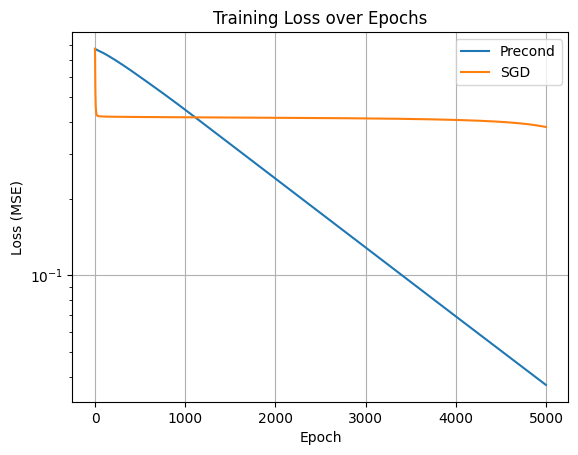

In [20]:
plt.semilogy(precond_losses,label='Precond')
plt.semilogy(sgd_losses, label='SGD')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)



## Before moving on to larger problems let's do a profile

In [21]:
@jax.jit
def train_step_new(state, batch_X, batch_y):
    def loss_fn(params):
        predictions = state.apply_fn(params, batch_X)
        loss = jnp.mean(jnp.square(predictions - batch_y))
        return loss, predictions

    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, predictions), grads = grad_fn({'params': state.params})

    jacobian = jax.jacobian(
        lambda params, perturbations, batch_X:
            state.apply_fn({'params': params, 'perturbations': perturbations}, X), argnums=1
    )(state.params, params['perturbations'], X)
    flattened, _ = jax.tree.flatten(
        jacobian
    )
    together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
    global_adjoints = [
        block_diag(*jnp.split(leaf, len(batch_X), axis=0)) for leaf in together
    ]
    global_adjoints.append(jnp.eye(batch_X.shape[0]))

    # Evaluate layers; refactor later
    _, intermediates = state.apply_fn(
        {'params': state.params}, batch_X, mutable=['intermediates']
    )

    k_list = []
    for layer_num in range(len(model.features)):
        layer = MLP_Layer(num_units=model.features[layer_num])
        def apply_layer(params):
            return layer.apply(
                params,
                intermediates['intermediates'][f'layer_{layer_num}_output'][0]
                # intermediates['intermediates'][f'layer_{layer_num}_output'][0]
            )
        k_i = jax.jacrev(apply_layer, argnums=0)
        flattened, _ = jax.tree.flatten(
            k_i(
            {'params': state.params[f'layers_{layer_num}']}
        ))

        reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
        aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
        k_list.append(aggregated_array)

    flattened, back = jax.flatten_util.ravel_pytree(grads)
    altered = get_correction(
        k_list, global_adjoints, flattened,lamb=1e-1
    )
    # grads = back(altered)

    # state = state.apply_gradients(grads=grads['params'])
    return altered
optimizer = optax.sgd(1e-5)
state = train_state.TrainState.create(
    apply_fn=model.apply, params=params['params'], tx=optimizer
)


In [22]:
train_step_new(state, X, y).block_until_ready()
%timeit train_step_new(state, X, y).block_until_ready()

6.05 ms ± 3.15 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
@jax.jit
def train_step_old(state, batch_X, batch_y):
    def loss_fn(params):
        predictions = state.apply_fn(params, batch_X)
        loss = jnp.mean(jnp.square(predictions - batch_y))
        return loss, predictions

    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
    (loss, predictions), grads = grad_fn({'params': state.params})

    jacobian = jax.jacobian(
        lambda params, perturbations, batch_X:
            state.apply_fn({'params': params, 'perturbations': perturbations}, X), 
        argnums=0
    )(state.params, params['perturbations'], X)
    flattened, _ = jax.tree.flatten(
        jacobian
    )
    
    # Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
    reshaped_leaves = [leaf.reshape(len(batch_X) * model.features[-1], 1, -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
    J = aggregated_array.reshape((len(batch_X) * model.features[-1], -1))
    jtj = J.T @ J
    
    lm_mat = lamb * jnp.eye(jtj.shape[0]) + jtj
    flattened, back = jax.flatten_util.ravel_pytree(grads)
    altered = jnp.linalg.solve(lm_mat, flattened) # Solve directly 
    # grads = back(altered) # Convert vector back to PyTree

    # state = state.apply_gradients(grads=grads['params'])
    return altered

optimizer = optax.sgd(1e-5)
state = train_state.TrainState.create(
    apply_fn=model.apply, params=params['params'], tx=optimizer
)


In [24]:
train_step_old(state, X, y).block_until_ready()
%timeit train_step_old(state, X, y).block_until_ready()

16.5 ms ± 122 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
